# Standard problem 4

## Problem specification

The sample is a thin film cuboid with dimensions:

- length $l_{x} = 500 \,\text{nm}$,
- width $l_{y} = 125 \,\text{nm}$, and
- thickness $l_{z} = 3 \,\text{nm}$.

The material parameters (similar to permalloy) are:

- exchange energy constant $A = 1.3 \times 10^{-11} \,\text{J/m}$,
- magnetisation saturation $M_\text{s} = 8 \times 10^{5} \,\text{A/m}$.

Magnetisation dynamics are governed by the Landau-Lifshitz-Gilbert equation

$$\frac{d\mathbf{m}}{dt} = \underbrace{-\gamma_{0}(\mathbf{m} \times \mathbf{H}_\text{eff})}_\text{precession} + \underbrace{\alpha\left(\mathbf{m} \times \frac{d\mathbf{m}}{dt}\right)}_\text{damping}$$

where $\gamma_{0} = 2.211 \times 10^{5} \,\text{m}\,\text{A}^{-1}\,\text{s}^{-1}$ and Gilbert damping $\alpha=0.02$.

In the standard problem 4, the system is first relaxed at zero external magnetic field and then, starting from the obtained equlibrium configuration, the magnetisation dynamics are simulated for two external magnetic fields $\mathbf{B}_{1} = (-24.6, 4.3, 0.0) \,\text{mT}$ and $\mathbf{B}_{2} = (-35.5, -6.3, 0.0) \,\text{mT}$.

More detailed specification of Standard problem 4 can be found in Ref. 1.

## Simulation

### Import modules
In the first step, we import the required modules and configure pyvista for static rendering.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import os
import sys
import pyvista as pv
from scipy import constants

os.environ["JAX_PLATFORMS"] = "cpu"

import neuralmag as nm

repo_root = Path.cwd().resolve()
if not (repo_root / "demos").exists():
    for parent in repo_root.parents:
        if (parent / "demos").exists():
            repo_root = parent
            break
sys.path.insert(0, str(repo_root / "demos"))

from _static_method_compare import SOLVER_LABELS, compare_static_methods, print_static_method_summary

pv.set_jupyter_backend("static")

METHODS = ("llg", "bb")
SELECTED_METHOD = "bb"

2026-04-22 12:09:17 NeuralMag:INFO [NeuralMag] Version 0.9.4


### Setup mesh and state

In the first stage, we need to setup the mesh and the simulation state. We chose a cell size of $5 \times 5 \times 3 \,\text{nm}^3$ resulting in $100 \times 25 \times 1$ cells simulate for the geometry defined for this standard problem.

In [2]:
mesh = nm.Mesh([100, 25, 1], [5e-9, 5e-9, 3e-9], [0.0, 0.0, 0.0])
state = nm.State(mesh)

2025-05-12 21:31:01 NeuralMag:INFO [Mesh] 3D, 100 x 25 x 1 (size = 5e-09 x 5e-09 x 3e-09)
2025-05-12 21:31:02 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.
2025-05-12 21:31:02 NeuralMag:INFO [NeuralMag] Set default device to 'TFRT_CPU_0'.
2025-05-12 21:31:02 NeuralMag:INFO [NeuralMag] Set default dtype to 'float32'.
2025-05-12 21:31:02 NeuralMag:INFO [State] Running on device: TFRT_CPU_0 (dtype = float32, backend = jax)


### Setup material parameters and define initial magnetization
In the next step, we set the material parameters $M_s$, $A$ and $\alpha$ according to the requirements of the standard problem.

In [3]:
state.material.Ms = 8e5
state.material.A = 1.3e-11
state.material.alpha = 0.02

We have to provide an initial magnetisation configuration that is going to be relaxed subsequently. We choose the uniform configuration in xy-direction that is know to relax into the requires s-state.

In [4]:
state.m = nm.VectorFunction(state).fill((0.5**0.5, 0.5**0.5, 0))

### Register effectiv-field contributions
Now we initialize the effecitive field contributions that are required for the relaxation of the initial magnetization. Namely, we set up a total field consisting of the exchange field and the demagnetization field.

In [5]:
nm.ExchangeField().register(state, "exchange")
nm.DemagField().register(state, "demag")
nm.TotalField("exchange", "demag").register(state)

2025-05-12 21:31:03 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange')
2025-05-12 21:31:03 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag')
2025-05-12 21:31:03 NeuralMag:INFO [DemagField]: Set up demag tensor
2025-05-12 21:31:05 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E')


### Minimize energy to find the initial stable state
We compare the damped-LLG relaxer and the BB steepest-descent minimizer for the zero-field relaxation stage. The switching dynamics that follow are still simulated with the LLG solver, because BB is a static minimizer rather than a time integrator.

2026-04-22 12:09:18 NeuralMag:INFO [Mesh] 3D, 100 x 25 x 1 (size = 5e-09 x 5e-09 x 3e-09)
2026-04-22 12:09:18 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.
2026-04-22 12:09:18 NeuralMag:INFO [NeuralMag] Set default device to 'cpu:0'.
2026-04-22 12:09:18 NeuralMag:INFO [NeuralMag] Set default dtype to 'float32'.
2026-04-22 12:09:19 NeuralMag:INFO [State] Running on device: cpu:0 (dtype = float32, backend = jax)
2026-04-22 12:09:19 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-22 12:09:19 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-22 12:09:19 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-04-22 12:09:21 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-04-22 12:09:21 NeuralMag:INFO [LLGSolverJAX] Initialize RHS function
2026-04-22 12:09:23 NeuralMag:INFO [LL

Standard problem 4 initial s-state method comparison
- LLG relax: runtime = 8.77s, E = 6.338341e-19 J
- BB steepest descent: runtime = 3.74s, E = 6.347748e-19 J, ΔE vs LLG = 9.408e-22 J, BB iterations = 95


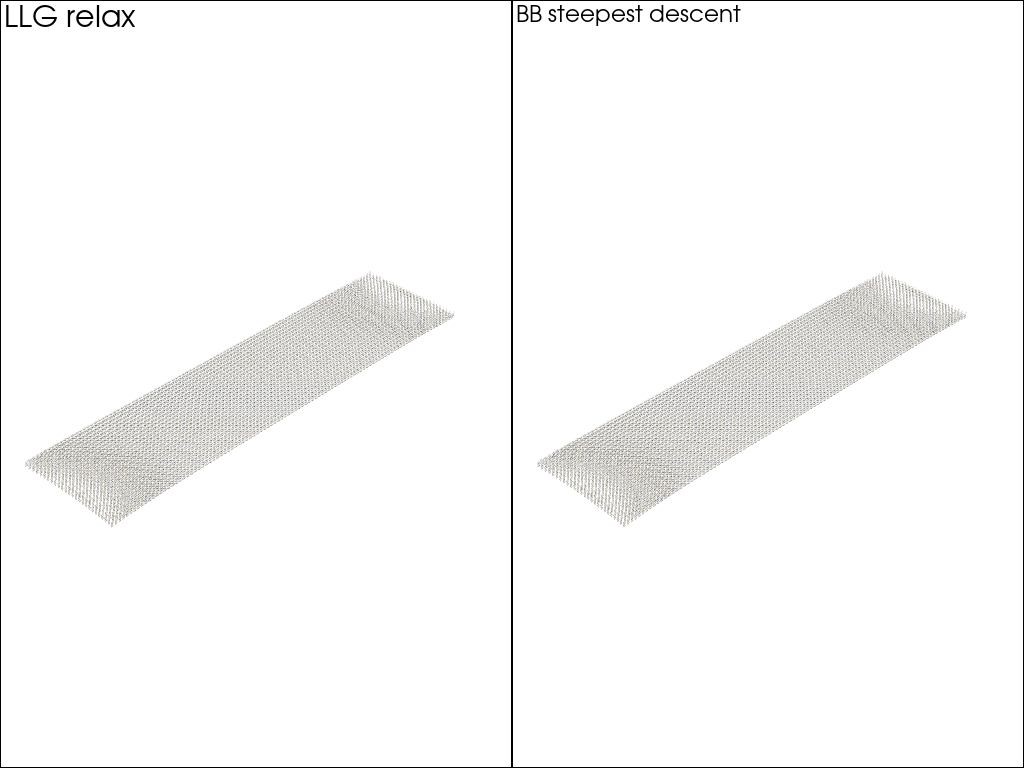

: 

In [ ]:
def build_relaxed_state():
    mesh = nm.Mesh([100, 25, 1], [5e-9, 5e-9, 3e-9], [0.0, 0.0, 0.0])
    state = nm.State(mesh)

    state.material.Ms = 8e5
    state.material.A = 1.3e-11
    state.material.alpha = 0.02

    state.m = nm.VectorFunction(state).fill((0.5**0.5, 0.5**0.5, 0))

    nm.ExchangeField().register(state, "exchange")
    nm.DemagField().register(state, "demag")
    nm.TotalField("exchange", "demag").register(state)
    return state

comparison = compare_static_methods(build_relaxed_state, methods=METHODS)
print_static_method_summary("Standard problem 4 initial s-state", comparison)

for method, values in comparison.items():
    values["state"].write_vti(["m"], f"standard-problem-4/s-state-{method}.vti")

plotter = pv.Plotter(shape=(1, len(METHODS)))
for column, method in enumerate(METHODS):
    mesh = pv.read(f"standard-problem-4/s-state-{method}.vti")
    glyphs = mesh.glyph(orient="m", scale="m", factor=1e-8)
    plotter.subplot(0, column)
    plotter.add_text(SOLVER_LABELS[method], font_size=12)
    plotter.add_mesh(glyphs, color="white", lighting=True, smooth_shading=True)

plotter.link_views()
plotter.show()

state = comparison[SELECTED_METHOD]["state"]

### Apply external field
In the next step we initialize the external field used to switch the magnetization as defined in the standard problem. The equilibrium state can come from either the damped-LLG relaxer or the BB minimizer, but the switching dynamics themselves are still simulated with the LLG solver.

In [ ]:
# Setup Zeeman field
h_ext = nm.VectorFunction(state).fill(
    [-24.6e-3 / constants.mu_0, 4.3e-3 / constants.mu_0, 0.0]  # B1
    # [-35.5e-3 / constants.mu_0, -6.3e-3 / constants.mu_0, 0.0]  # B2
)
nm.ExternalField(h_ext).register(state, "external")

# Update total field
nm.TotalField("exchange", "demag", "external").register(state)

# Initialize LLGSolver for dynamics
llg = nm.LLGSolver(state)

2025-05-12 21:31:23 NeuralMag:INFO [ExternalField] Register state methods (field: 'h_external', energy: 'E_external')
2025-05-12 21:31:23 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E')
2025-05-12 21:31:23 NeuralMag:INFO [LLGSolverJAX] Initialize RHS function


### Simulate switching
Finally, we can run the switching simulation using the LLGSolver. We run the magnetisation evolution for $t=1 \,\text{ns}$. We set up a logger to save the averaged magnetization as well as a time series of the full magnetization configuration and log the simulation state every $10\,\text{ps}$.

In [8]:
logger = nm.Logger("standard-problem-4", ["t", "m"], ["m"])
while state.t < 1e-9:
    llg.step(1.0e-11)
    logger.log(state)

2025-05-12 21:31:23 NeuralMag:INFO [LLGSolverJAX] Step: dt = 1e-11s, t = 0s
2025-05-12 21:31:27 NeuralMag:INFO [LLGSolverJAX] Step: dt = 1e-11s, t = 1e-11s
2025-05-12 21:31:27 NeuralMag:INFO [LLGSolverJAX] Step: dt = 1e-11s, t = 2e-11s
2025-05-12 21:31:28 NeuralMag:INFO [LLGSolverJAX] Step: dt = 1e-11s, t = 3e-11s
2025-05-12 21:31:28 NeuralMag:INFO [LLGSolverJAX] Step: dt = 1e-11s, t = 4e-11s
2025-05-12 21:31:28 NeuralMag:INFO [LLGSolverJAX] Step: dt = 1e-11s, t = 5e-11s
2025-05-12 21:31:28 NeuralMag:INFO [LLGSolverJAX] Step: dt = 1e-11s, t = 6e-11s
2025-05-12 21:31:28 NeuralMag:INFO [LLGSolverJAX] Step: dt = 1e-11s, t = 7e-11s
2025-05-12 21:31:28 NeuralMag:INFO [LLGSolverJAX] Step: dt = 1e-11s, t = 8e-11s
2025-05-12 21:31:28 NeuralMag:INFO [LLGSolverJAX] Step: dt = 1e-11s, t = 9e-11s
2025-05-12 21:31:28 NeuralMag:INFO [LLGSolverJAX] Step: dt = 1e-11s, t = 1e-10s
2025-05-12 21:31:28 NeuralMag:INFO [LLGSolverJAX] Step: dt = 1e-11s, t = 1.1e-10s
2025-05-12 21:31:28 NeuralMag:INFO [LLGSol

### Postprocessing

Finally, we want to plot the average magnetization configuration as a function of time `t`:

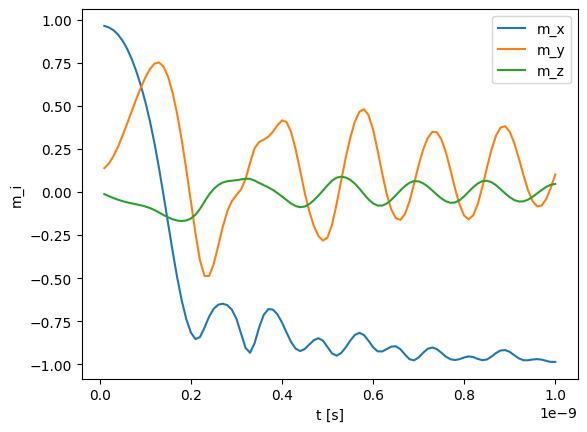

In [9]:
data = np.loadtxt("standard-problem-4/log.dat")
plt.plot(data[:, 0], data[:, 1], label="m_x")
plt.plot(data[:, 0], data[:, 2], label="m_y")
plt.plot(data[:, 0], data[:, 3], label="m_z")
plt.legend()
plt.xlabel("t [s]")
plt.ylabel("m_i")
plt.show()

## References

[1] µMAG Site Directory: http://www.ctcms.nist.gov/~rdm/mumag.org.html
    
This tutorial was adapted from [Ubermag](https://ubermag.github.io/).